In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
list_c_vals=[np.float64(0.9930733865293206), np.float64(0.9920967260182538), np.float64(0.9909671201993773), np.float64(0.989884569072691), np.float64(0.9886490726381949), np.float64(0.9873606308958891), np.float64(0.9860192438457734), np.float64(0.9845249114878482), np.float64(0.9829776338221131), np.float64(0.9812774108485682), np.float64(0.9794242425672137), np.float64(0.9777181289780494), np.float64(0.9756590700810754), np.float64(0.9734470658762916), np.float64(0.971182116363698), np.float64(0.9686642215432947), np.float64(0.9658933814150816), np.float64(0.9626695959790589), np.float64(0.9594928652352263), np.float64(0.9561631891835839)]

list_ef_AC_stark_vals=[np.float64(1.9848907245309517), np.float64(1.9326217272530353), np.float64(1.8874574125355859), np.float64(1.8532977803786037), np.float64(1.8243428307820888), np.float64(1.7795925637460406), np.float64(1.7607469792704598), np.float64(1.6987060773553462), np.float64(1.6576698580006997), np.float64(1.6236383212065206), np.float64(1.5903114669728082), np.float64(1.5349892952995634), np.float64(1.4927718061867854), np.float64(1.4361589996344748), np.float64(1.3832508756426312), np.float64(1.327347434211255), np.float64(1.2630486753403458), np.float64(1.2030545990299033), np.float64(1.1460652052799285), np.float64(1.0801804940904207)]


## Simulaatio

In [5]:
f_1 = qubit.frequency*1.2 #Ajotaajuudet
f_2 = qubit.frequency*1.4
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7 #Hilbert-avaruuden dimensio

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

In [6]:
def find_params(f_1,f_2,A,evolution,f_rabi,AC_stark,lims,scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range, max_range):
        delta = AC_stark+i/scale
        AC_stark_vals.append(delta)
        
        if A < 2.9:
            sim_vals = pulses.sim_3_part_pulses(f_1,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=10,f_2=f_2,K=200, drag=True)
        elif A < 3.7:
            sim_vals = pulses.sim_3_part_pulses(f_1,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=5,f_2=f_2,K=200, drag=True)
        else:
            sim_vals = pulses.sim_3_part_pulses(f_1,f_ef+delta,A,evolution,dim,f_rabi,t_ramp=5,U_f=1,f_2=f_2,K=200, drag=True)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.semilogy(AC_stark_vals, max_f_vals)
    plt.xlabel("delta=ω_supp-ω_ef (GHz)")
    plt.ylabel("Suurin f-tason todennäköisyys")
    plt.show()
    
    index=np.argmin(max_f_vals)
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    delta=AC_stark_vals[index]
    pi_pulse=pulse_times[index]
    
    return(delta,pi_pulse,[e_max,f_max],max_e_vals)

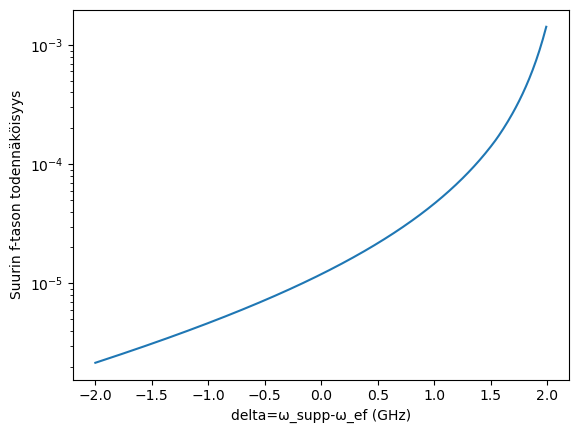

Amplitudi (GHz): 2.0390881111606896
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9969664038192996
F-tason suurin todennäköisyys: 2.2617791523132386e-06
Pulssin pituus (ns): 196.17175076434157
Rabi-taajuus (fourier):  0.0025291270883155085


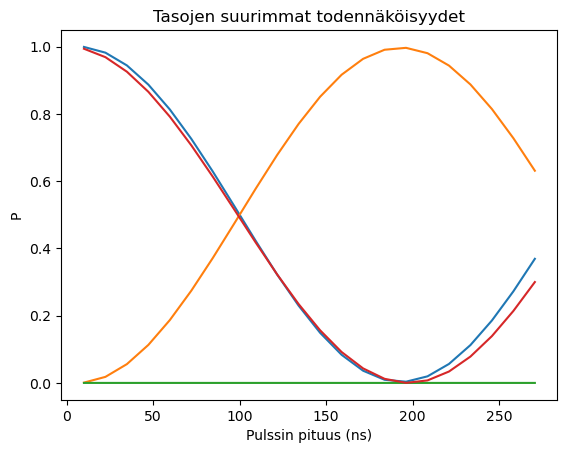

---------------------------------------------


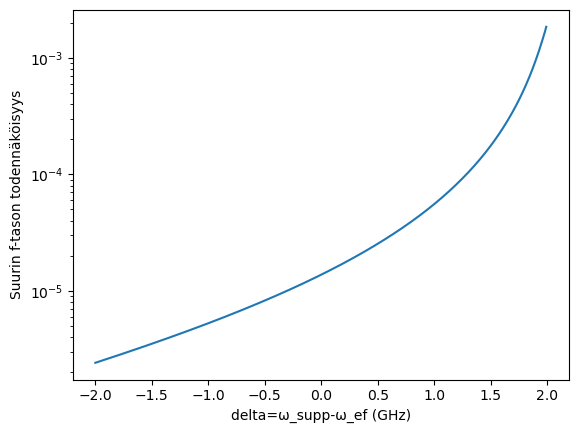

Amplitudi (GHz): 2.173238644789682
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9973752468443368
F-tason suurin todennäköisyys: 2.4835316469783652e-06
Pulssin pituus (ns): 159.08402066774735
Rabi-taajuus (fourier):  0.003078910747018282


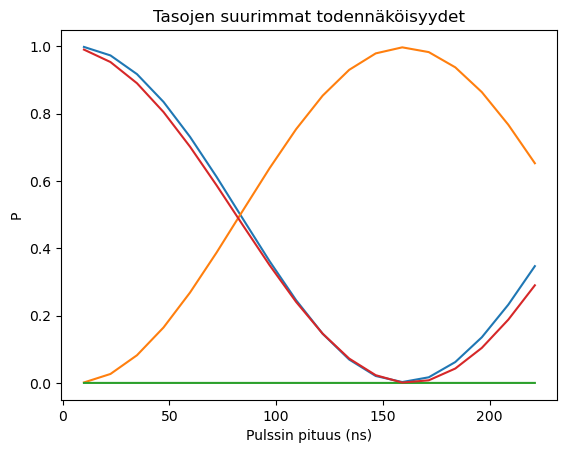

---------------------------------------------


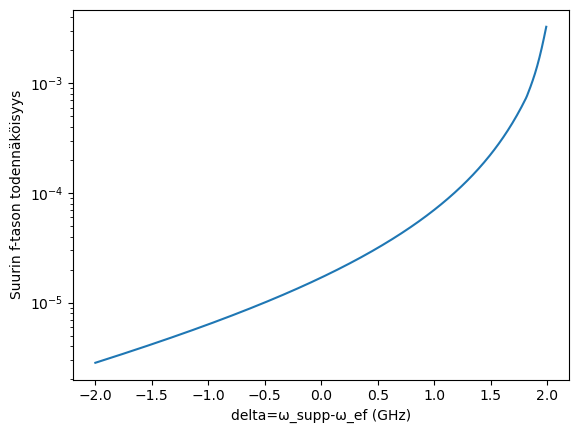

Amplitudi (GHz): 2.307389178418675
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.999046495583043
F-tason suurin todennäköisyys: 2.830074313917477e-06
Pulssin pituus (ns): 134.37830158646102
Rabi-taajuus (fourier):  0.0037026258592970165


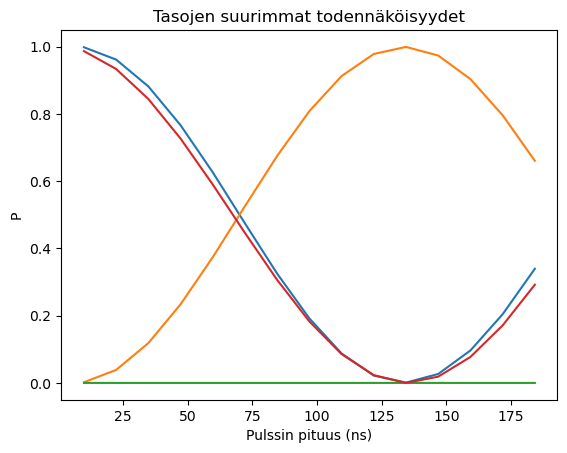

---------------------------------------------


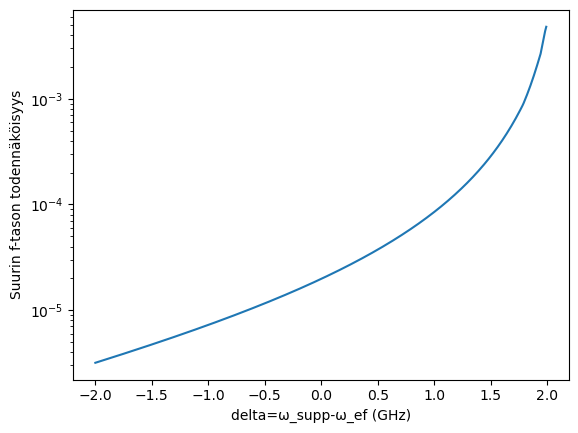

Amplitudi (GHz): 2.4415397120476676
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9997049384772401
F-tason suurin todennäköisyys: 3.1832433783917823e-06
Pulssin pituus (ns): 109.6114587007963
Rabi-taajuus (fourier):  0.004392064986359873


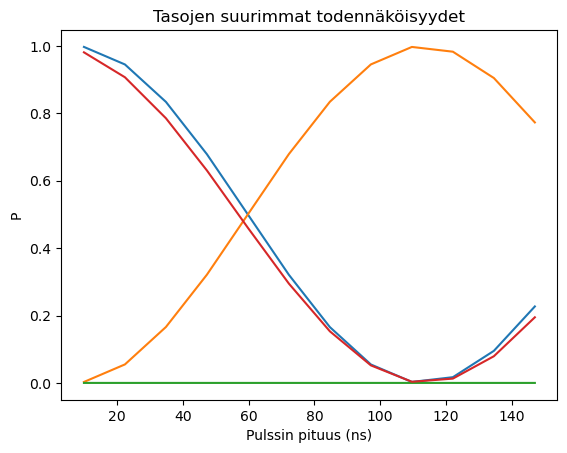

---------------------------------------------


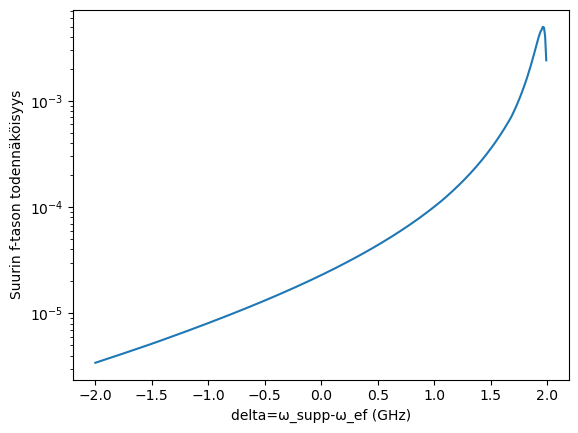

Amplitudi (GHz): 2.57569024567666
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9997968294721041
F-tason suurin todennäköisyys: 3.7397699409580315e-06
Pulssin pituus (ns): 97.26894863378055
Rabi-taajuus (fourier):  0.005198913368461063


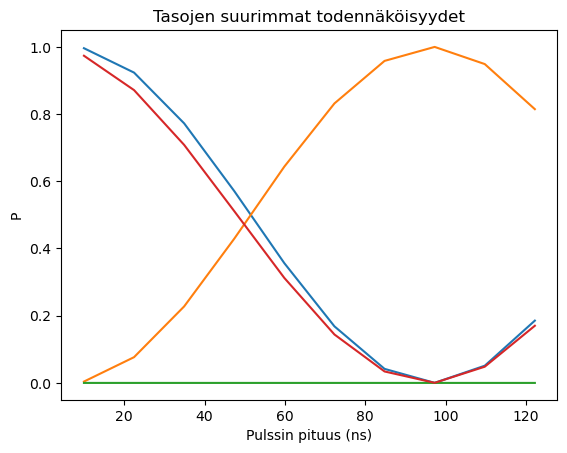

---------------------------------------------


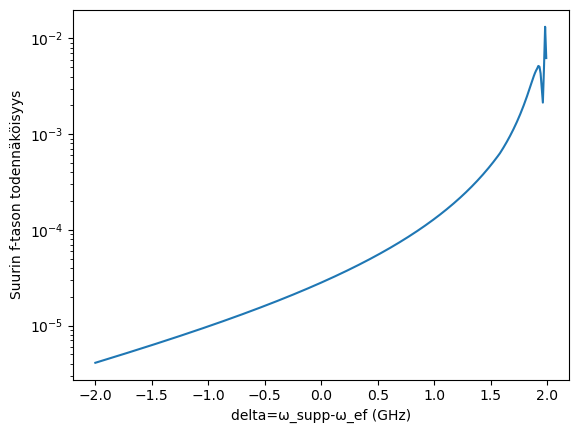

Amplitudi (GHz): 2.7098407793056527
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9987542119112945
F-tason suurin todennäköisyys: 4.160923719700171e-06
Pulssin pituus (ns): 84.89956768476095
Rabi-taajuus (fourier):  0.0060951184798803395


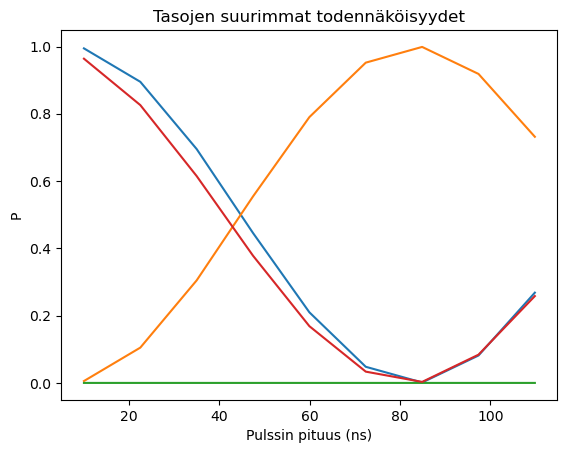

---------------------------------------------


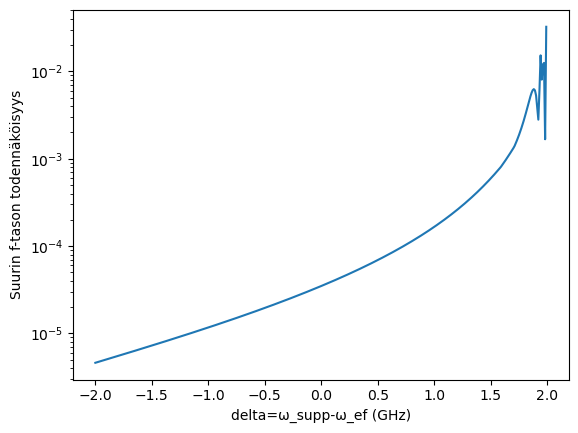

Amplitudi (GHz): 2.8439913129346457
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9999144913296767
F-tason suurin todennäköisyys: 4.775209394226655e-06
Pulssin pituus (ns): 72.50121795680874
Rabi-taajuus (fourier):  0.008101107953991356


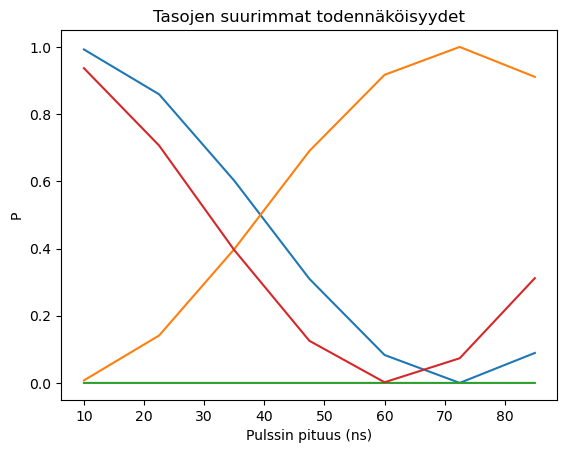

---------------------------------------------


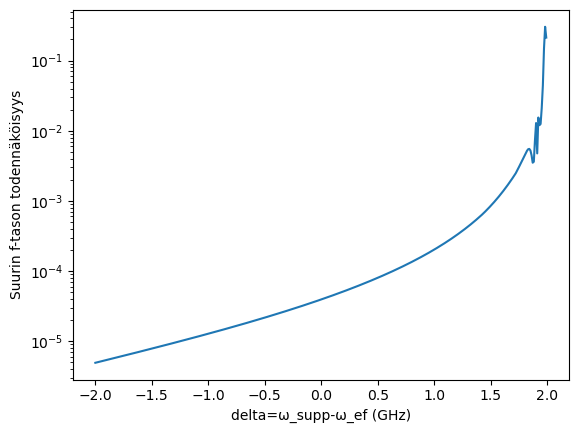

Amplitudi (GHz): 2.9781418465636382
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9999201644221188
F-tason suurin todennäköisyys: 5.130796104668531e-06
Pulssin pituus (ns): 60.07686688279241
Rabi-taajuus (fourier):  0.009328724294292016


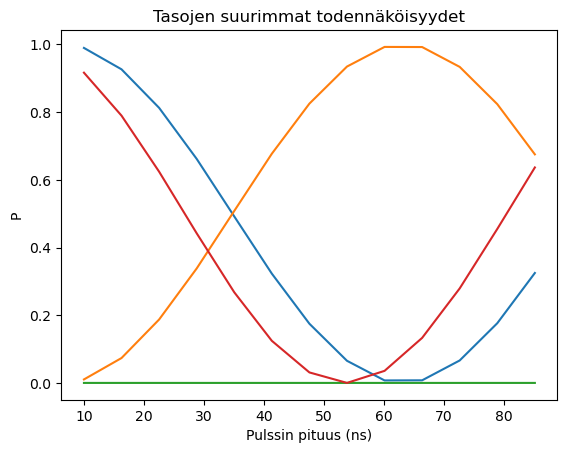

---------------------------------------------


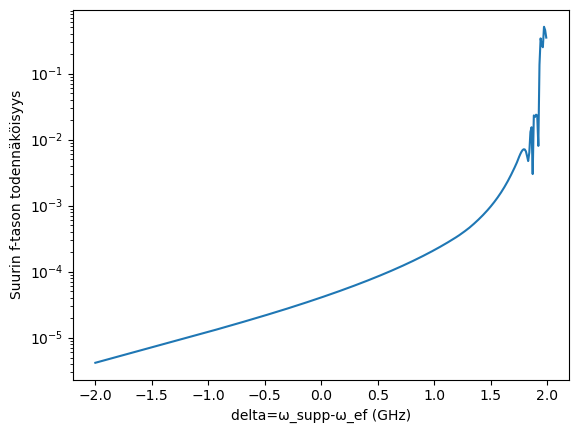

Amplitudi (GHz): 3.112292380192631
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.999949503254885
F-tason suurin todennäköisyys: 5.469710889995109e-06
Pulssin pituus (ns): 53.88623004646665
Rabi-taajuus (fourier):  0.010813785341870566


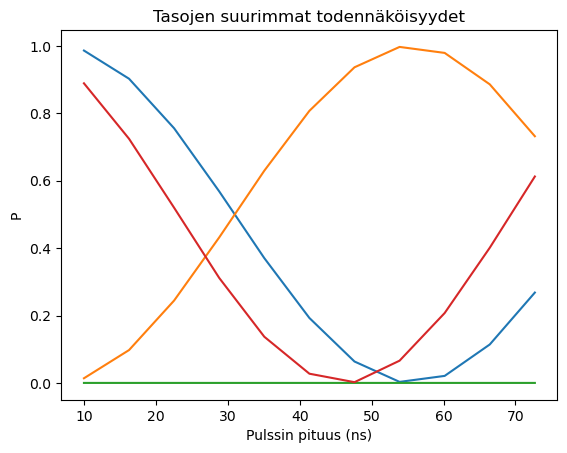

---------------------------------------------


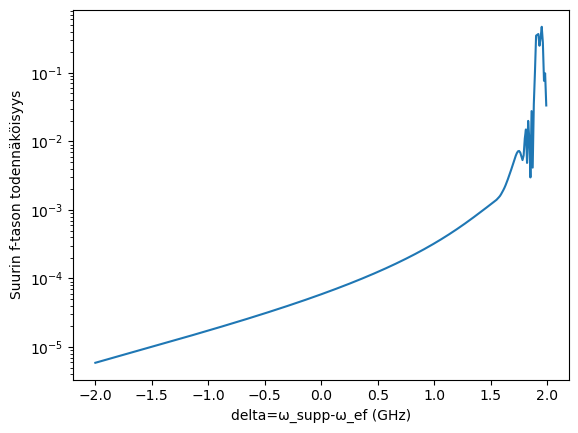

Amplitudi (GHz): 3.2464429138216238
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9992742840787434
F-tason suurin todennäköisyys: 6.084665737497702e-06
Pulssin pituus (ns): 47.68194579099885
Rabi-taajuus (fourier):  0.01092737376583966


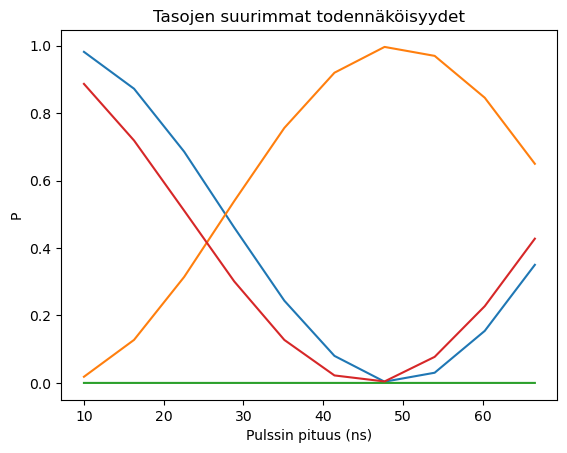

---------------------------------------------


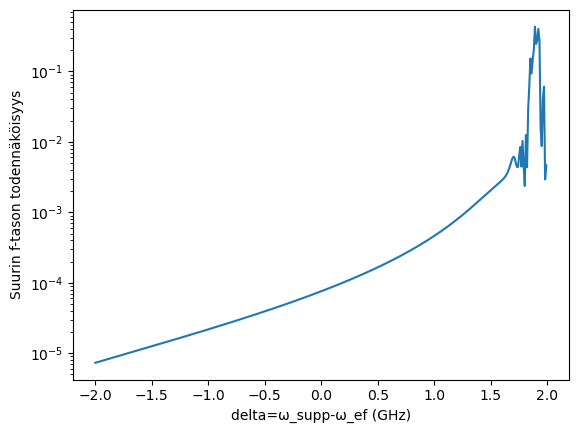

Amplitudi (GHz): 3.3805934474506167
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9977572360727986
F-tason suurin todennäköisyys: 7.357692329453566e-06
Pulssin pituus (ns): 41.46103649000868
Rabi-taajuus (fourier):  0.01249985603910991


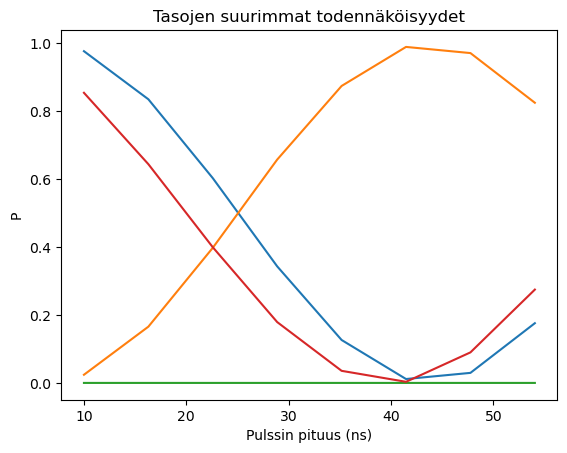

---------------------------------------------


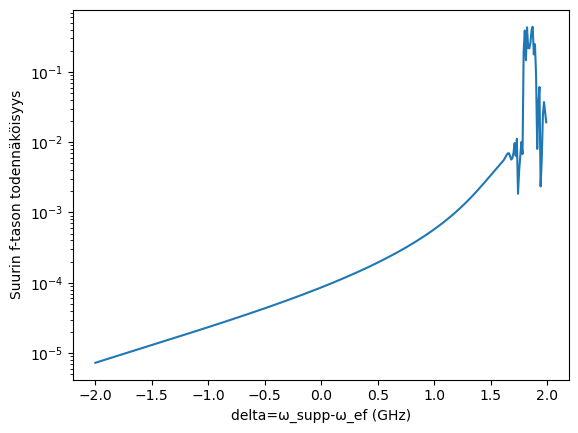

Amplitudi (GHz): 3.5147439810796093
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9993007412737063
F-tason suurin todennäköisyys: 7.266973317020057e-06
Pulssin pituus (ns): 41.51593585240559
Rabi-taajuus (fourier):  0.014237811335172474


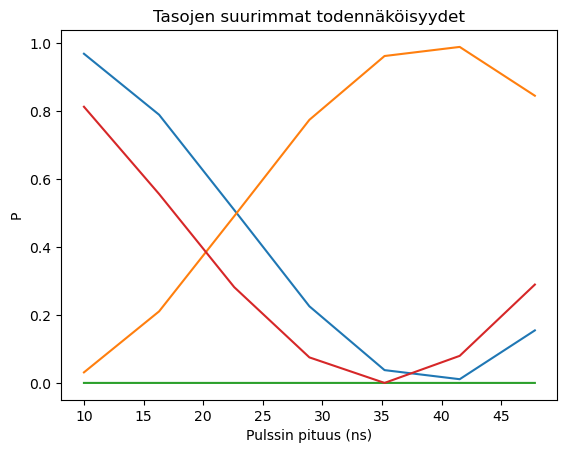

---------------------------------------------


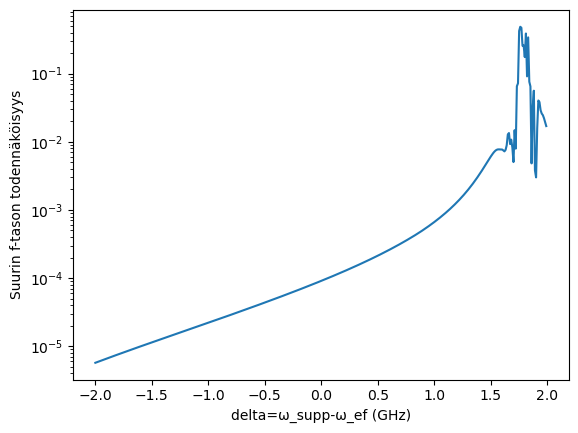

Amplitudi (GHz): 3.648894514708602
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9988794795921512
F-tason suurin todennäköisyys: 1.0491015048052987e-05
Pulssin pituus (ns): 35.26595839019518
Rabi-taajuus (fourier):  0.016297213013781585


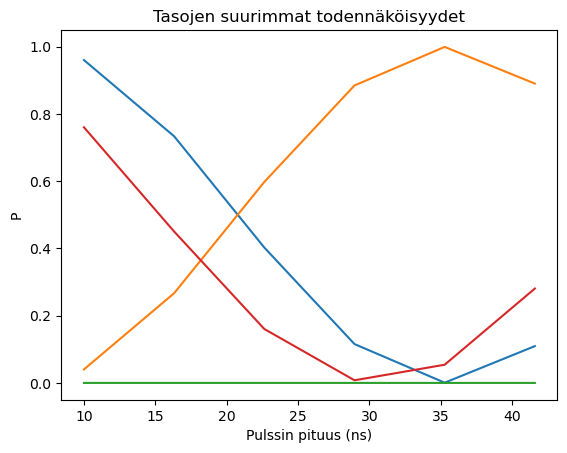

---------------------------------------------


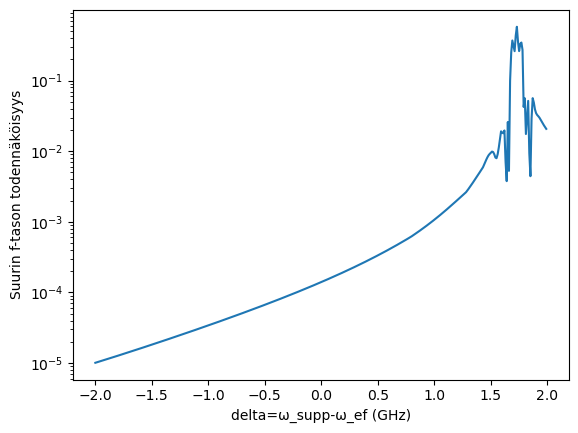

Amplitudi (GHz): 3.783045048337595
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9976381664562738
F-tason suurin todennäköisyys: 1.0564006280850173e-05
Pulssin pituus (ns): 31.524865585444203
Rabi-taajuus (fourier):  0.01824584094931471


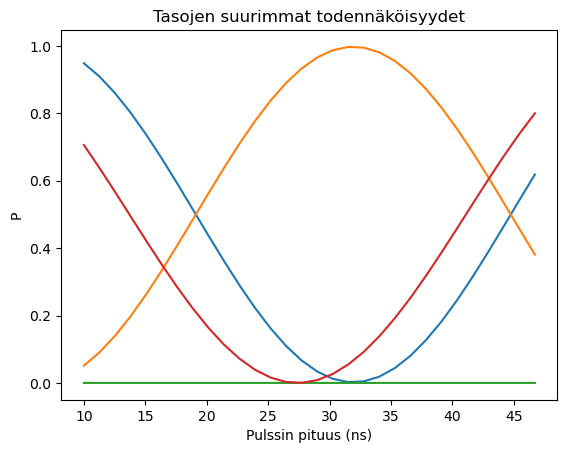

---------------------------------------------


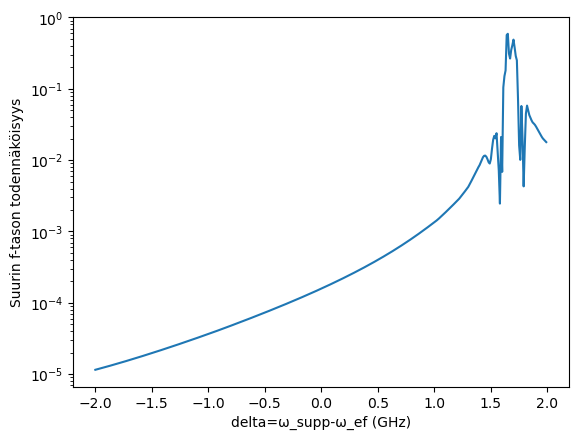

Amplitudi (GHz): 3.9171955819665873
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9975659182614292
F-tason suurin todennäköisyys: 1.2137400795969763e-05
Pulssin pituus (ns): 29.036822022616484
Rabi-taajuus (fourier):  0.02065777714888996


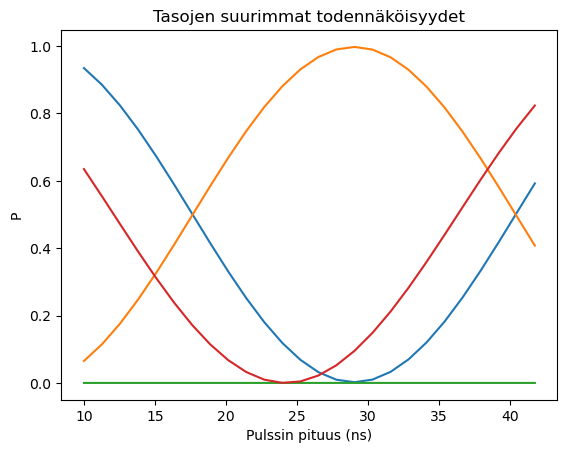

---------------------------------------------


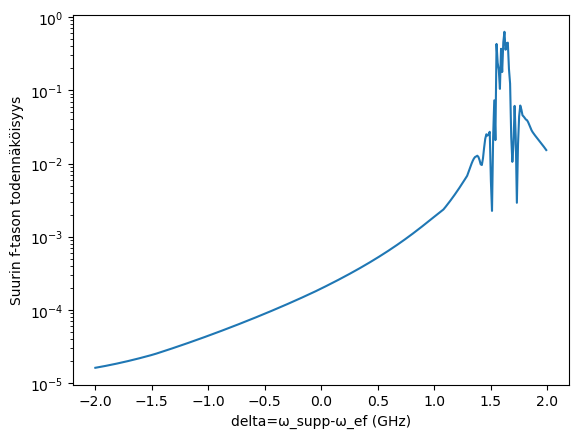

Amplitudi (GHz): 4.05134611559558
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9948224702561217
F-tason suurin todennäköisyys: 1.6457531035451057e-05
Pulssin pituus (ns): 26.541464624828283
Rabi-taajuus (fourier):  0.023212348690660408


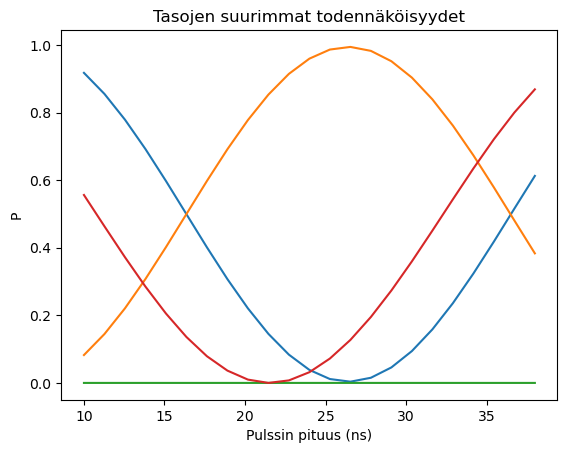

---------------------------------------------


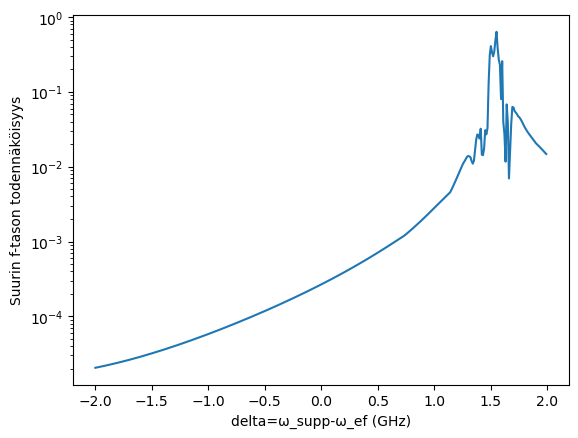

Amplitudi (GHz): 4.185496649224572
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9898798312607056
F-tason suurin todennäköisyys: 2.1682404082439333e-05
Pulssin pituus (ns): 24.03677576438463
Rabi-taajuus (fourier):  0.029853552274509084


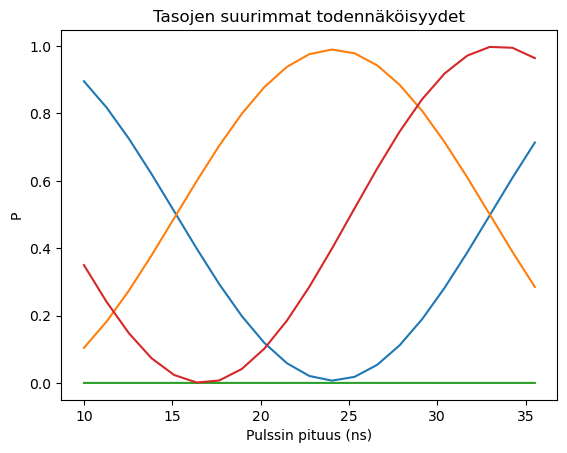

---------------------------------------------


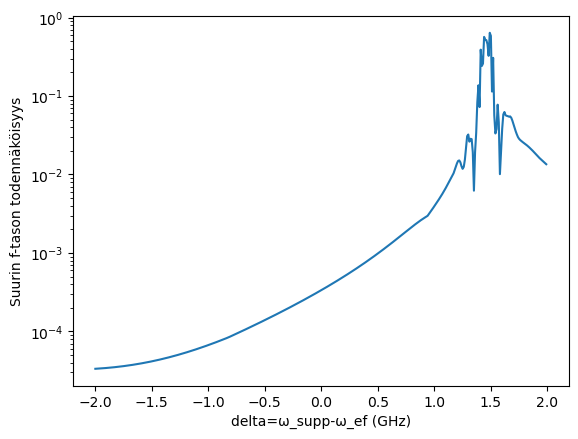

Amplitudi (GHz): 4.319647182853566
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.9793732500943506
F-tason suurin todennäköisyys: 3.344505261128641e-05
Pulssin pituus (ns): 21.523094431144308
Rabi-taajuus (fourier):  0.03323575326859691


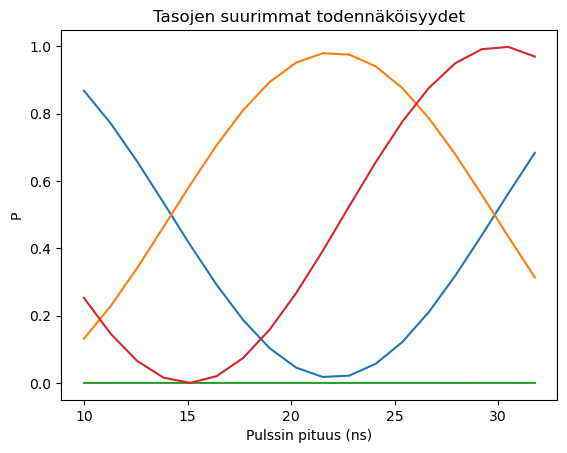

---------------------------------------------


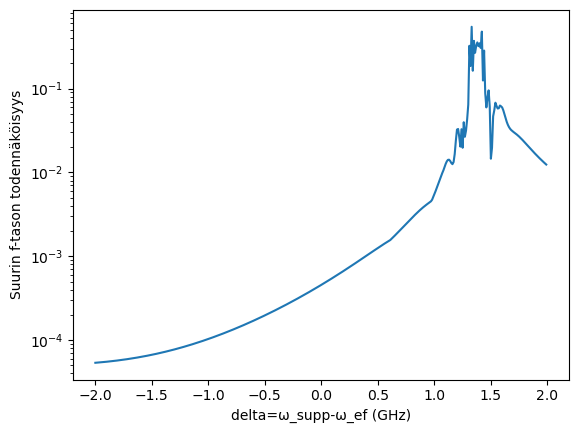

Amplitudi (GHz): 4.453797716482558
AC-stark siirtymä (GHz): -2.0
E-tason suurin todennäköisyys: 0.979144732407386
F-tason suurin todennäköisyys: 5.627496239960297e-05
Pulssin pituus (ns): 20.27666275002123
Rabi-taajuus (fourier):  0.03706965872277885


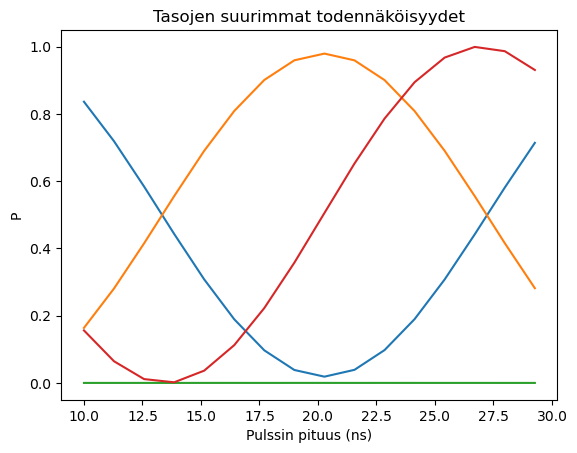

---------------------------------------------


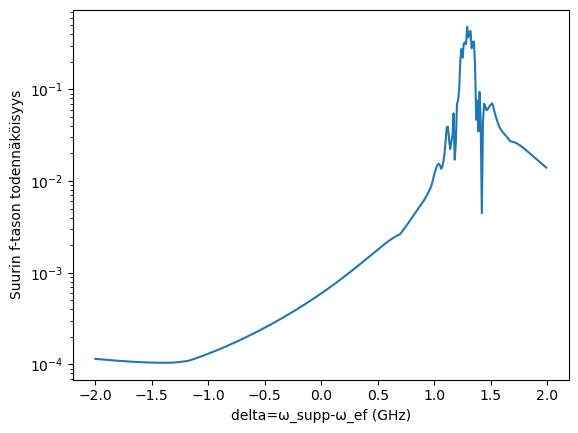

Amplitudi (GHz): 4.587948250111551
AC-stark siirtymä (GHz): -1.4
E-tason suurin todennäköisyys: 0.9847527154976673
F-tason suurin todennäköisyys: 0.00012047529240207323
Pulssin pituus (ns): 19.023393298644542
Rabi-taajuus (fourier):  0.04137394004419758


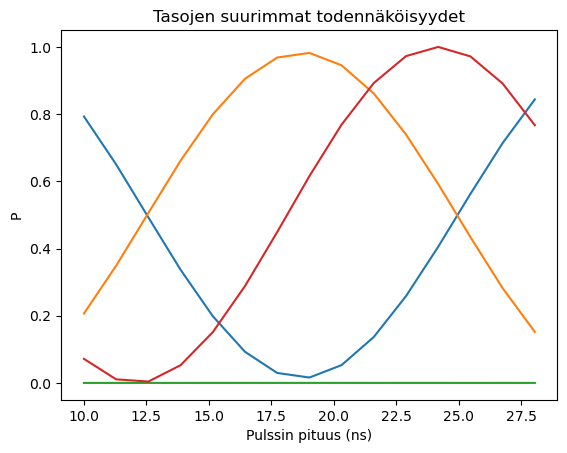

---------------------------------------------


In [7]:
c_vals = [] #c:n arvot
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals= []

min_range = 0.08
max_range = 0.18
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)
    
    f_1_opt=f_1*list_c_vals[i]
    f_2_opt=f_2*list_c_vals[i]

    f_rabi= 0.0009703*A**3 - 0.00434*A**2 + 0.009973*A - 0.007682 #Arvaus Rabi-taajuudelle
    AC_stark=0

    params=find_params(f_1_opt,f_2_opt, A, evolution_eigenbasis,8*f_rabi,AC_stark,[-200,200],100)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])

    m=10

    if A < 2.9:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=10,f_2=f_2_opt,K=200, drag=True)
    elif A < 3.7:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=5,f_2=f_2_opt,K=200, drag=True)
    else:
        vals = pulses.sim_3_part_pulses(f_1_opt,f_ef+deltas[-1],A,evolution_eigenbasis,dim,(f_rabi*8)/m,t_ramp=5,U_f=1,f_2=f_2_opt,K=200, drag=True)
    
    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("F-tason suurin todennäköisyys:", vals[1])
    print("Pulssin pituus (ns):", pulse_lengths[-1])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    max_vals.append([vals[0],vals[1]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 
    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

In [8]:
print(f_ef-qubit.frequency)

-2.4068995201121837


[np.float64(2.0390881111606896), np.float64(2.173238644789682), np.float64(2.307389178418675), np.float64(2.4415397120476676), np.float64(2.57569024567666), np.float64(2.7098407793056527), np.float64(2.8439913129346457), np.float64(2.9781418465636382), np.float64(3.112292380192631), np.float64(3.2464429138216238), np.float64(3.3805934474506167), np.float64(3.5147439810796093), np.float64(3.648894514708602), np.float64(3.783045048337595), np.float64(3.9171955819665873), np.float64(4.05134611559558), np.float64(4.185496649224572), np.float64(4.319647182853566), np.float64(4.453797716482558), np.float64(4.587948250111551)]


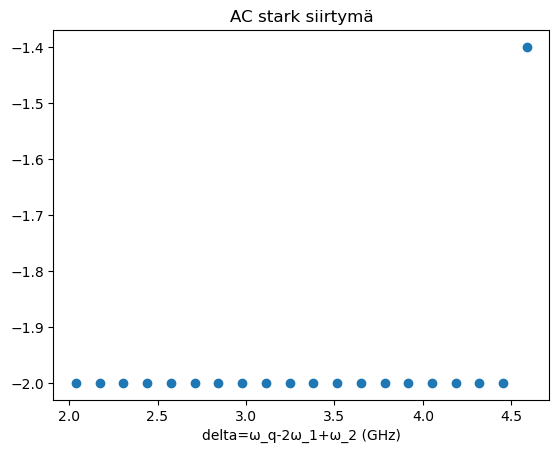

[-2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -1.4]
[]


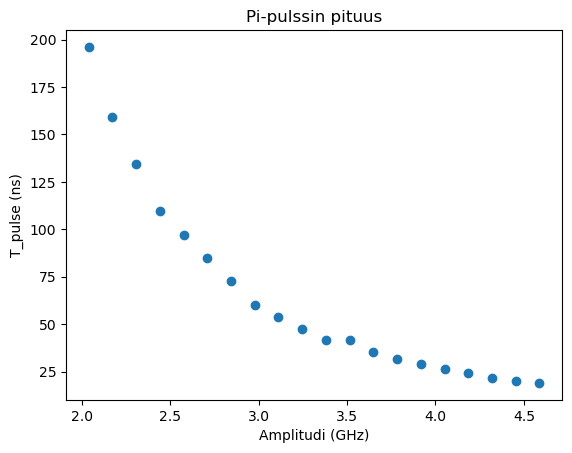

[np.float64(196.17175076434157), np.float64(159.08402066774735), np.float64(134.37830158646102), np.float64(109.6114587007963), np.float64(97.26894863378055), np.float64(84.89956768476095), np.float64(72.50121795680874), np.float64(60.07686688279241), np.float64(53.88623004646665), np.float64(47.68194579099885), np.float64(41.46103649000868), np.float64(41.51593585240559), np.float64(35.26595839019518), np.float64(31.524865585444203), np.float64(29.036822022616484), np.float64(26.541464624828283), np.float64(24.03677576438463), np.float64(21.523094431144308), np.float64(20.27666275002123), np.float64(19.023393298644542)]


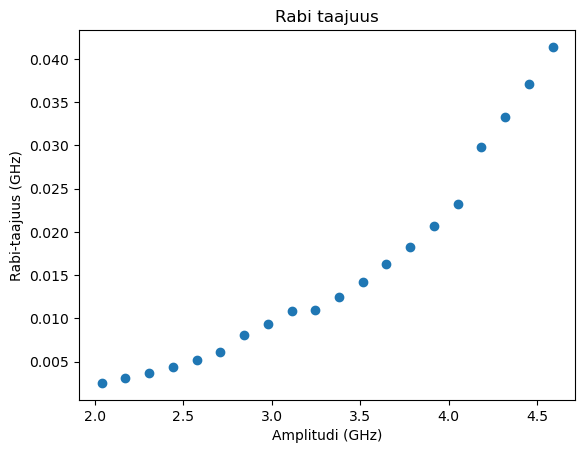

[np.float64(0.0025291270883155085), np.float64(0.003078910747018282), np.float64(0.0037026258592970165), np.float64(0.004392064986359873), np.float64(0.005198913368461063), np.float64(0.0060951184798803395), np.float64(0.008101107953991356), np.float64(0.009328724294292016), np.float64(0.010813785341870566), np.float64(0.01092737376583966), np.float64(0.01249985603910991), np.float64(0.014237811335172474), np.float64(0.016297213013781585), np.float64(0.01824584094931471), np.float64(0.02065777714888996), np.float64(0.023212348690660408), np.float64(0.029853552274509084), np.float64(0.03323575326859691), np.float64(0.03706965872277885), np.float64(0.04137394004419758)]


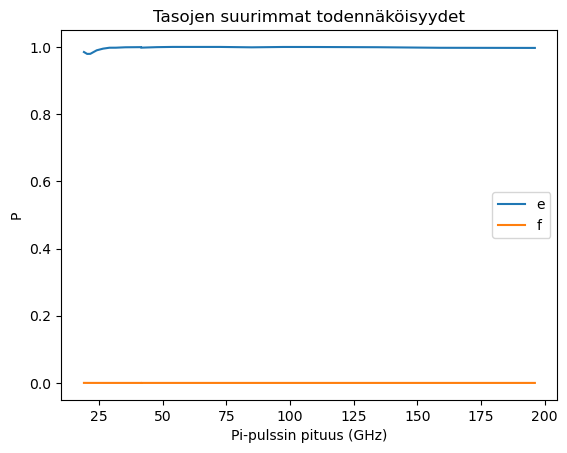

[np.float64(0.9969664038192996), np.float64(0.9973752468443368), np.float64(0.999046495583043), np.float64(0.9997049384772401), np.float64(0.9997968294721041), np.float64(0.9987542119112945), np.float64(0.9999144913296767), np.float64(0.9999201644221188), np.float64(0.999949503254885), np.float64(0.9992742840787434), np.float64(0.9977572360727986), np.float64(0.9993007412737063), np.float64(0.9988794795921512), np.float64(0.9976381664562738), np.float64(0.9975659182614292), np.float64(0.9948224702561217), np.float64(0.9898798312607056), np.float64(0.9793732500943506), np.float64(0.979144732407386), np.float64(0.9847527154976673)]
[np.float64(2.2617791523132386e-06), np.float64(2.4835316469783652e-06), np.float64(2.830074313917477e-06), np.float64(3.1832433783917823e-06), np.float64(3.7397699409580315e-06), np.float64(4.160923719700171e-06), np.float64(4.775209394226655e-06), np.float64(5.130796104668531e-06), np.float64(5.469710889995109e-06), np.float64(6.084665737497702e-06), np.floa

'\nplt.figure(figsize=(6, 6))\nplt.imshow(data, aspect=\'auto\')  # stretches to square\nplt.colorbar(label="e-tason suurin todennäköisyys")\nplt.show() '

In [9]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.xlabel("delta=ω_q-2ω_1+ω_2 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)
print(c_vals)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

"""
plt.figure(figsize=(6, 6))
plt.imshow(data, aspect='auto')  # stretches to square
plt.colorbar(label="e-tason suurin todennäköisyys")
plt.show() """